# Importing

## Import Library

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier


# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

## Import Dataset

In [2]:
df = sns.load_dataset("titanic")

# Preprocessing

## Frist five row

In [3]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## last Five row

In [4]:
df.tail()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
886,0,2,male,27.0,0,0,13.00,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.00,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.45,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.00,C,First,man,True,C,Cherbourg,yes,True
890,0,3,male,32.0,0,0,7.75,Q,Third,man,True,NaN,Queenstown,no,True


## Shape of our dataset

In [5]:
df.shape

(891, 15)

## List out all columns

In [6]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')

## Datatype of each columns

In [7]:
df.dtypes

survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
class          category
who              object
adult_male         bool
deck           category
embark_town      object
alive            object
alone              bool
dtype: object

## Information of all Columns

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


## Check Null Value

In [9]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

## Handle Missing Value

### Fill Age using Median

In [10]:
imp_median = SimpleImputer(strategy='median')
df[['age']] = imp_median.fit_transform(df[['age']])

### Fill Embarked using Mode

In [11]:
imp_mode = SimpleImputer(strategy='most_frequent')
df[['embarked']] = imp_mode.fit_transform(df[['embarked']])

## Check Dupicate Value

In [12]:
df.duplicated().sum()

np.int64(110)

## Summary

In [13]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.361582,0.523008,0.381594,32.204208
std,0.486592,0.836071,13.019697,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


# EDA

In [14]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

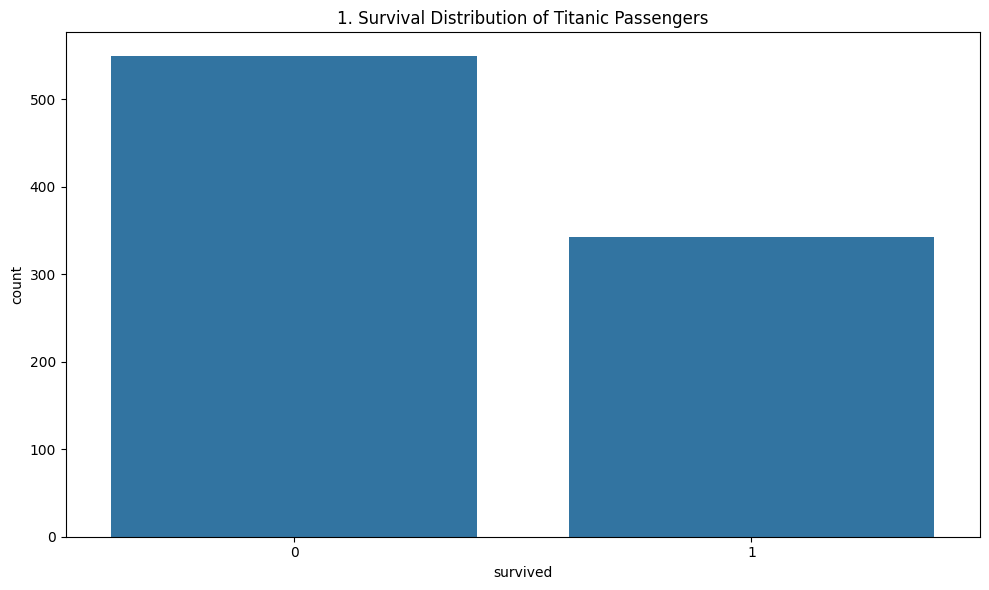

In [15]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='survived')
plt.title(f'{plot_no}. Survival Distribution of Titanic Passengers')
show_fig()
plot_no += 1

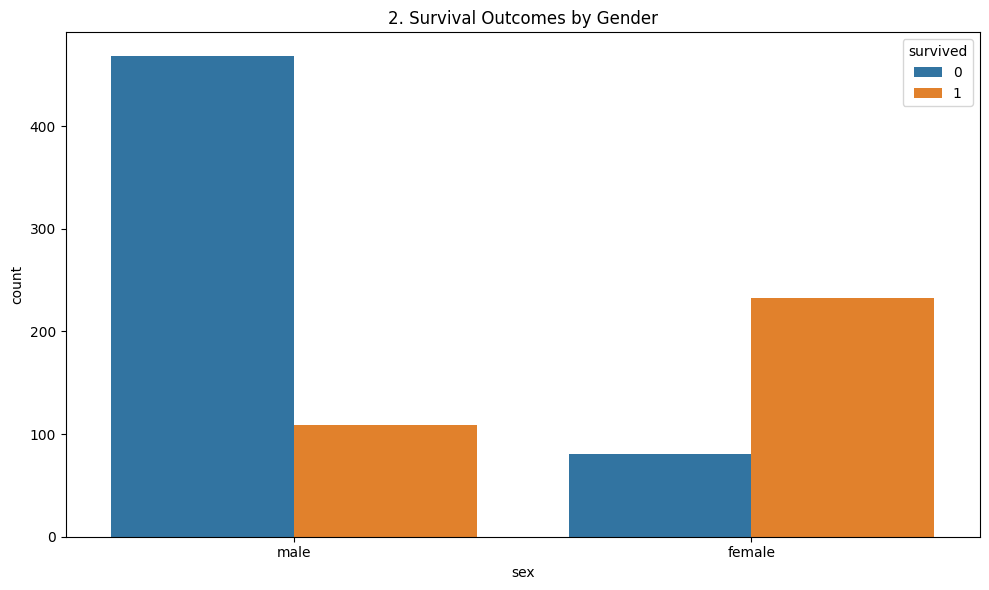

In [16]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='sex', hue='survived')
plt.title(f'{plot_no}. Survival Outcomes by Gender')
show_fig()
plot_no += 1

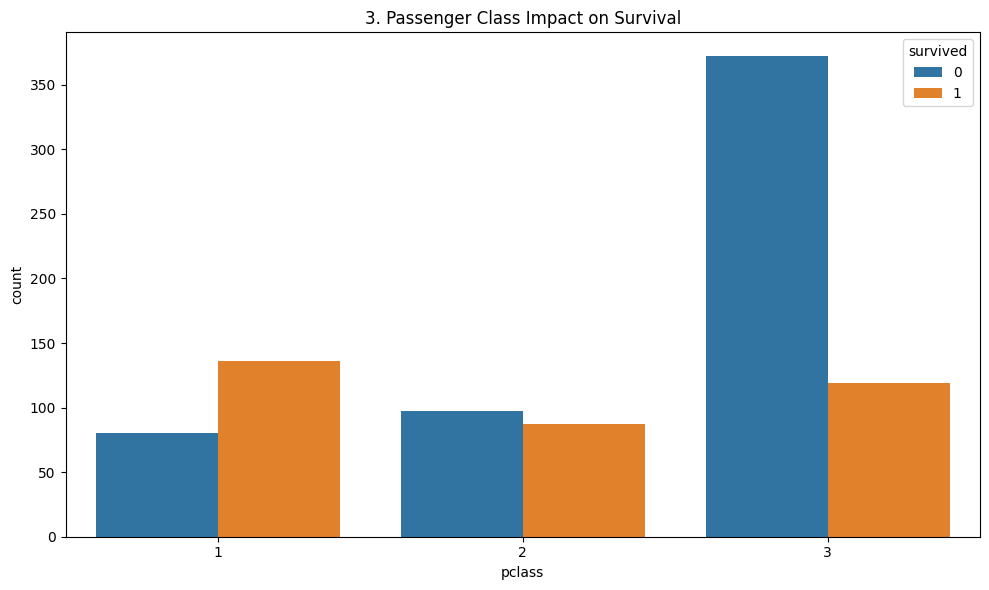

In [17]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='pclass', hue='survived')
plt.title(f'{plot_no}. Passenger Class Impact on Survival')
show_fig()
plot_no += 1

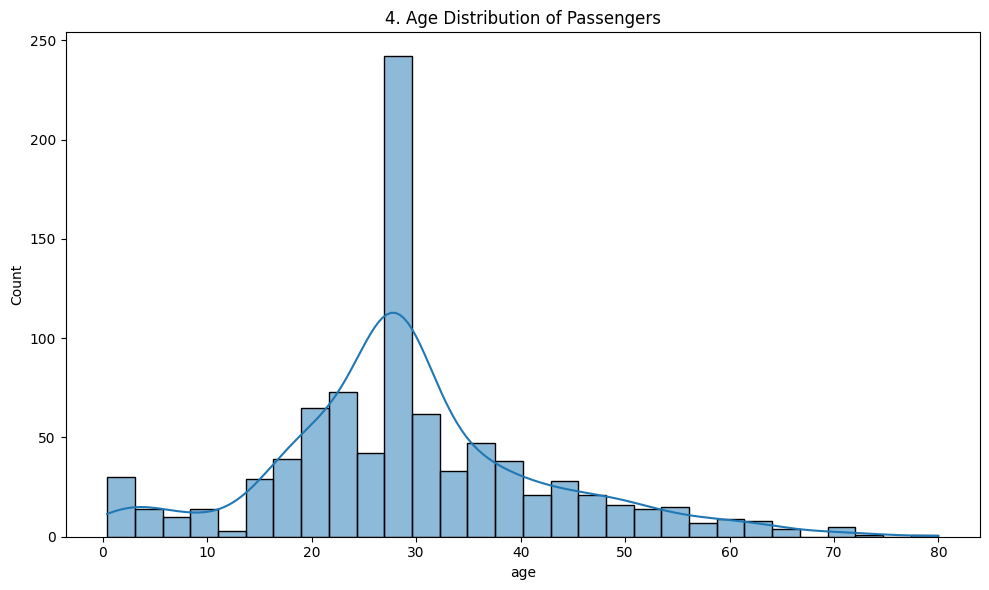

In [18]:
fig = plt.figure(figsize=(10,6))
sns.histplot(data=df, x='age', kde=True, bins=30)
plt.title(f'{plot_no}. Age Distribution of Passengers')
show_fig()
plot_no += 1

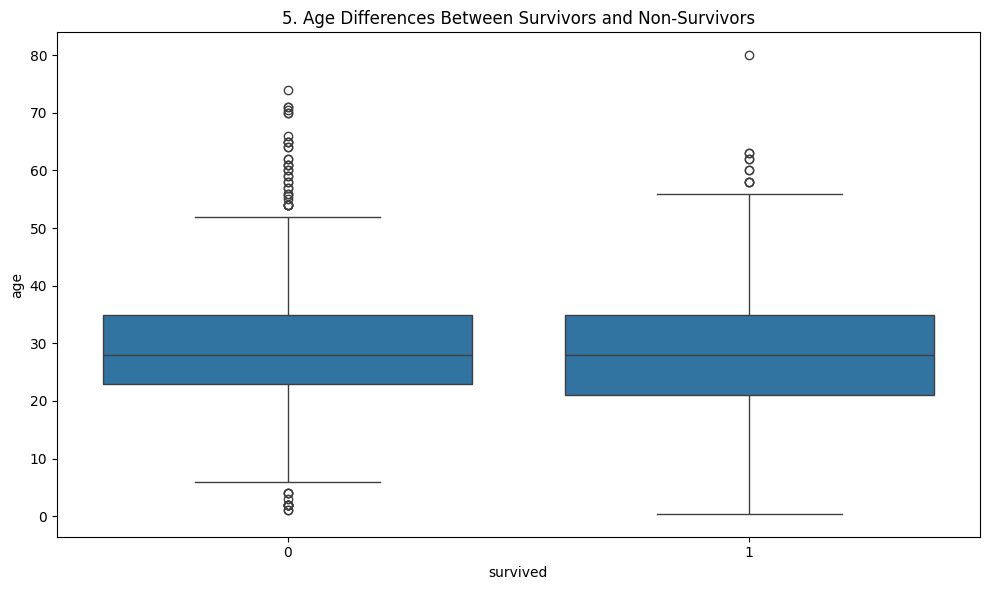

In [19]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='survived', y='age')
plt.title(f'{plot_no}. Age Differences Between Survivors and Non-Survivors')
show_fig()
plot_no += 1

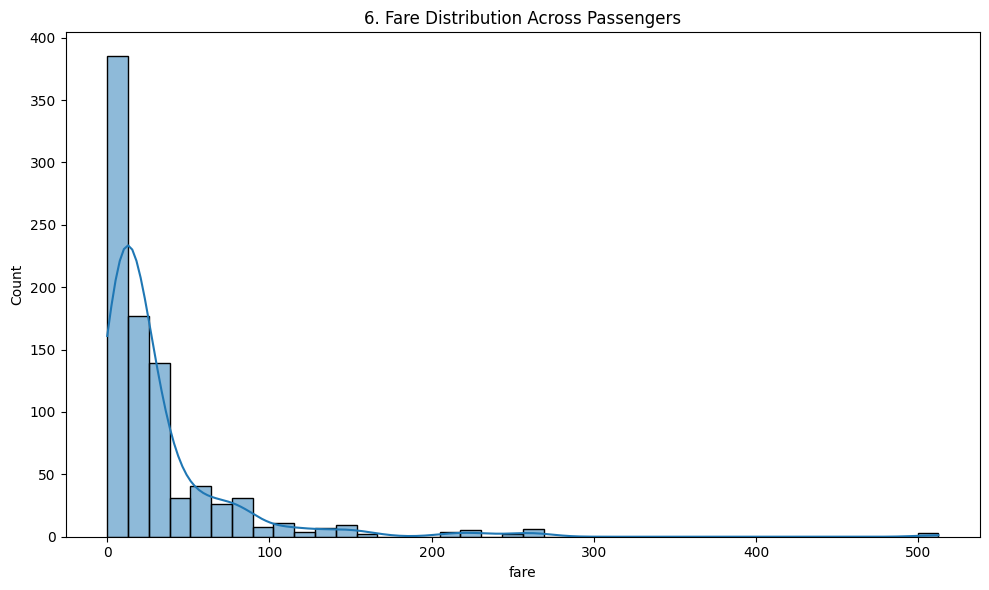

In [20]:
fig = plt.figure(figsize=(10,6))
sns.histplot(data=df, x='fare', kde=True, bins=40)
plt.title(f'{plot_no}. Fare Distribution Across Passengers')
show_fig()
plot_no += 1

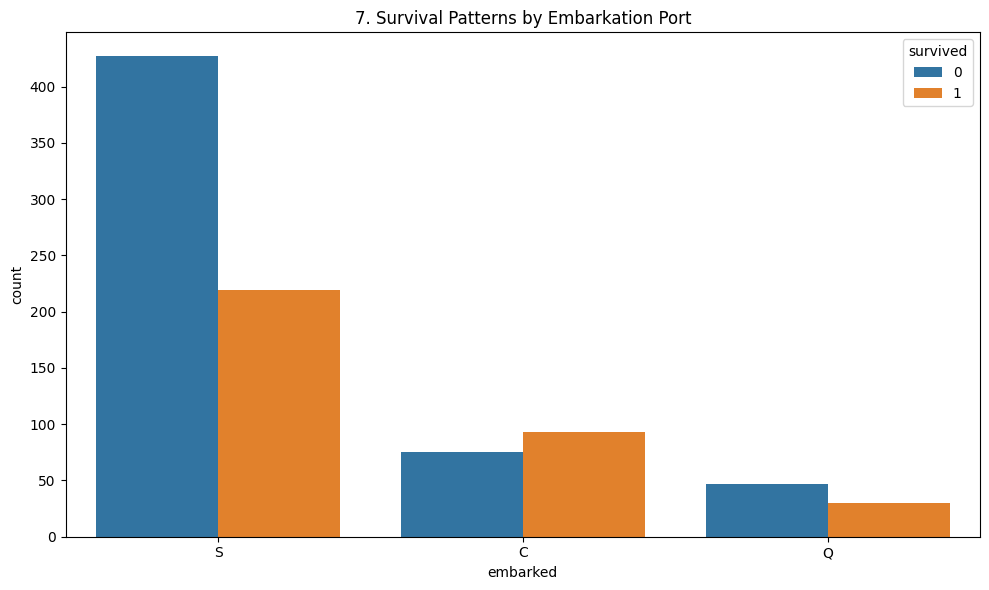

In [21]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='embarked', hue='survived')
plt.title(f'{plot_no}. Survival Patterns by Embarkation Port')
show_fig()
plot_no += 1

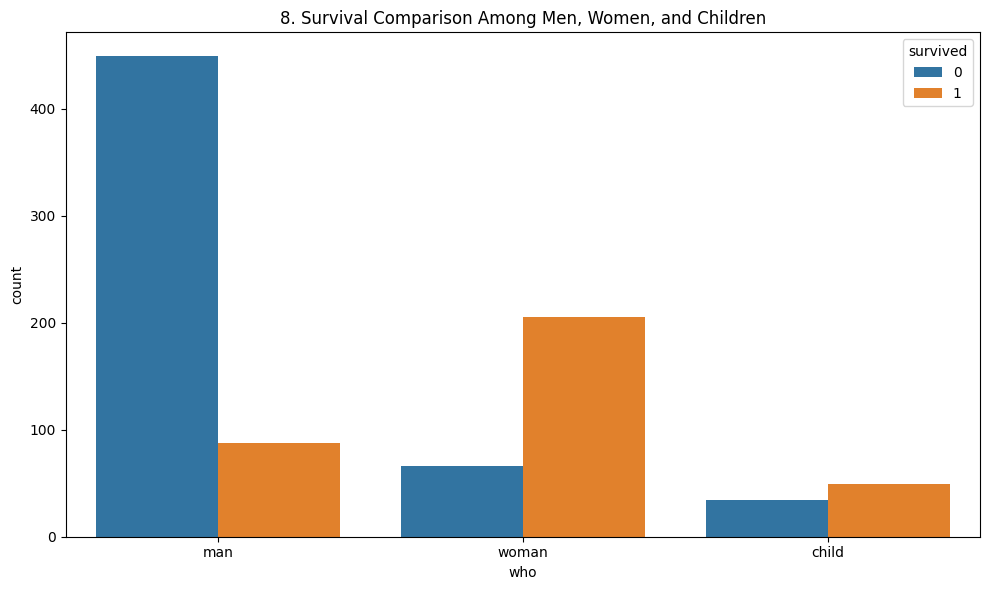

In [22]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='who', hue='survived')
plt.title(f'{plot_no}. Survival Comparison Among Men, Women, and Children')
show_fig()
plot_no += 1

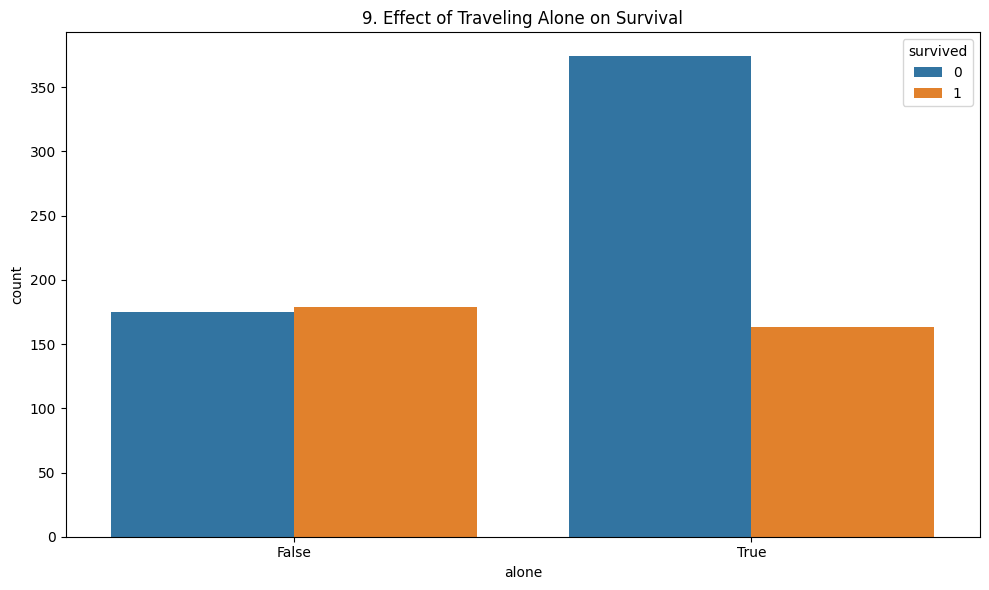

In [23]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='alone', hue='survived')
plt.title(f'{plot_no}. Effect of Traveling Alone on Survival')
show_fig()
plot_no += 1

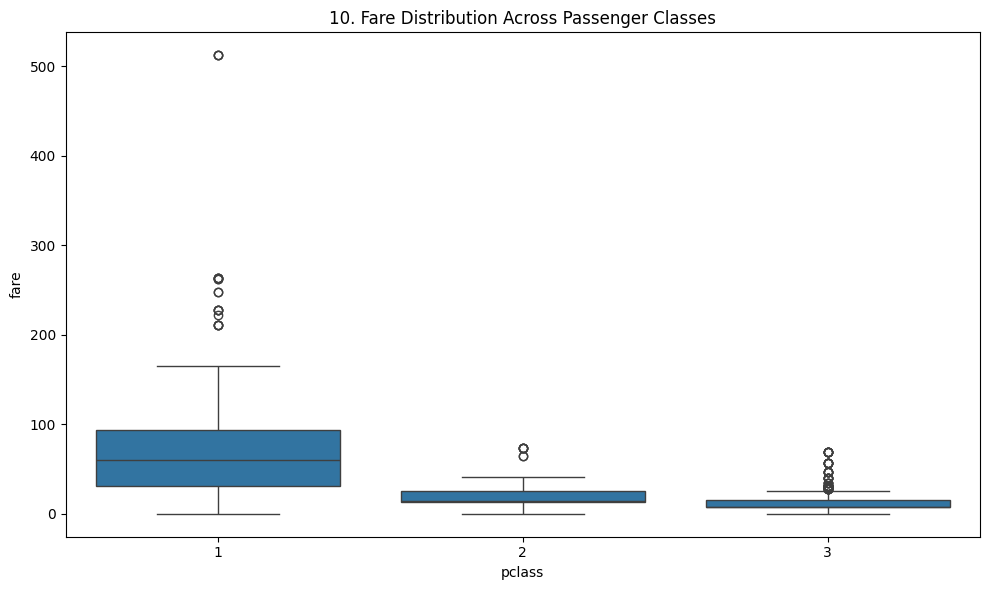

In [24]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='pclass', y='fare')
plt.title(f'{plot_no}. Fare Distribution Across Passenger Classes')
show_fig()
plot_no += 1

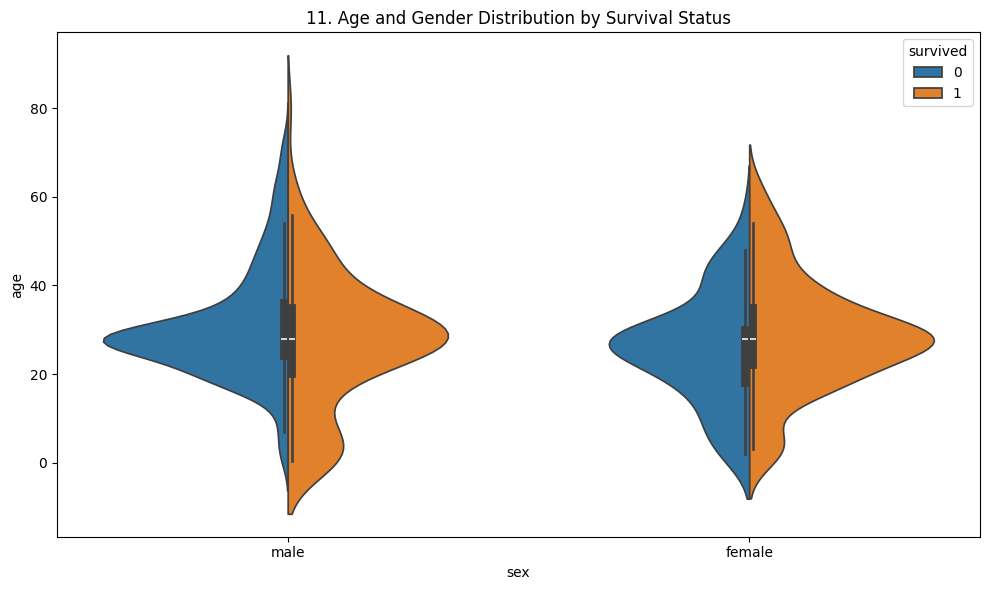

In [25]:
fig = plt.figure(figsize=(10,6))
sns.violinplot(data=df, x='sex', y='age', hue='survived', split=True)
plt.title(f'{plot_no}. Age and Gender Distribution by Survival Status')
show_fig()
plot_no += 1

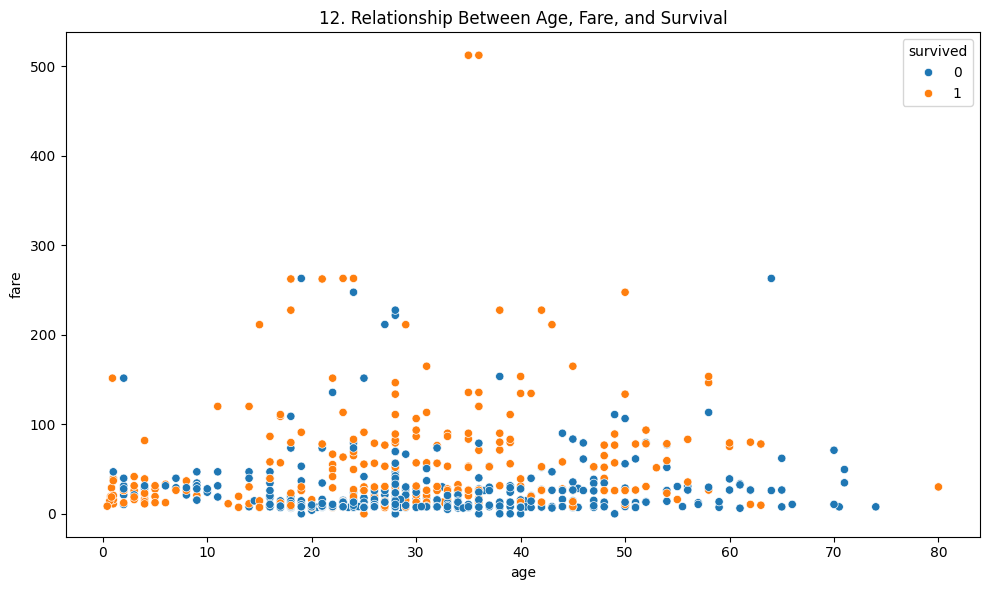

In [26]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='age', y='fare', hue='survived')
plt.title(f'{plot_no}. Relationship Between Age, Fare, and Survival')
show_fig()
plot_no += 1

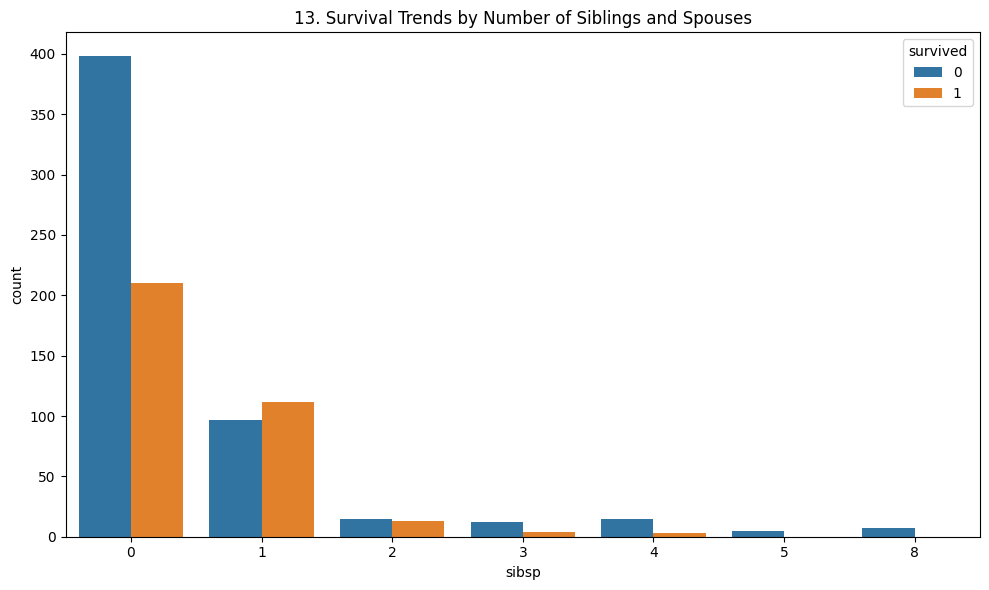

In [27]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='sibsp', hue='survived')
plt.title(f'{plot_no}. Survival Trends by Number of Siblings and Spouses')
show_fig()
plot_no += 1

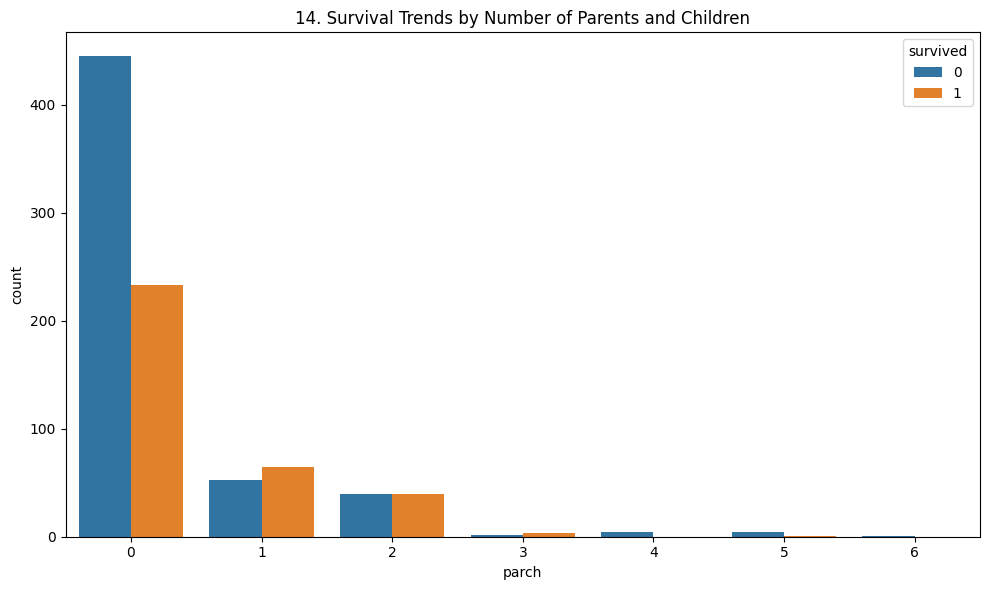

In [28]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='parch', hue='survived')
plt.title(f'{plot_no}. Survival Trends by Number of Parents and Children')
show_fig()
plot_no += 1

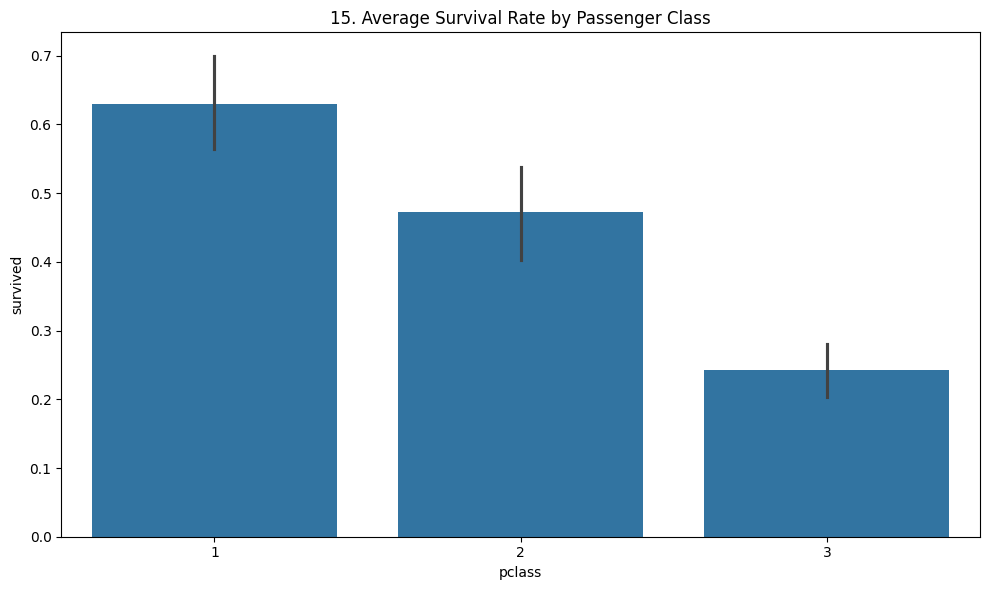

In [29]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='pclass', y='survived')
plt.title(f'{plot_no}. Average Survival Rate by Passenger Class')
show_fig()
plot_no += 1

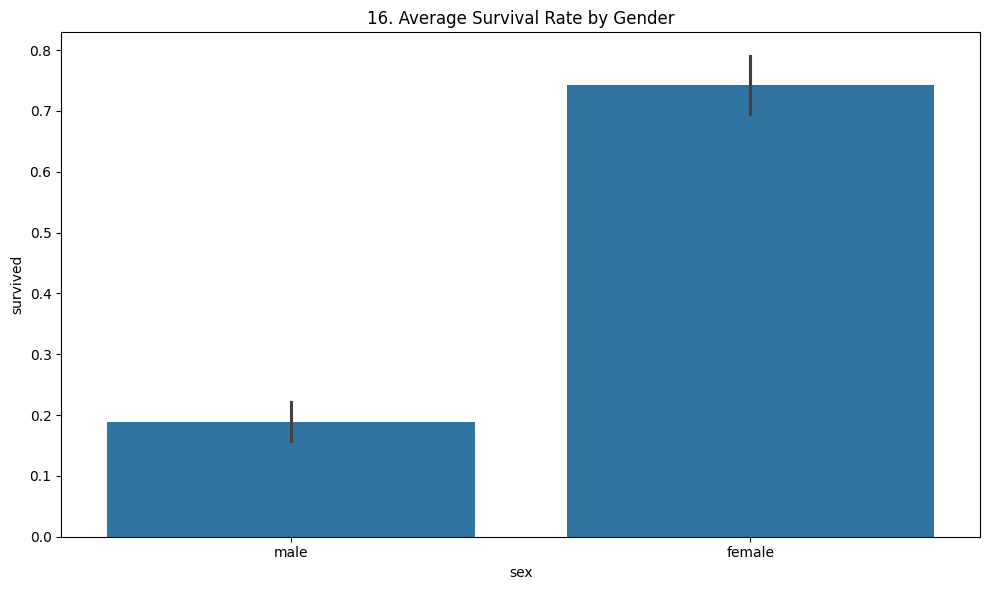

In [30]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='sex', y='survived')
plt.title(f'{plot_no}. Average Survival Rate by Gender')
show_fig()
plot_no += 1

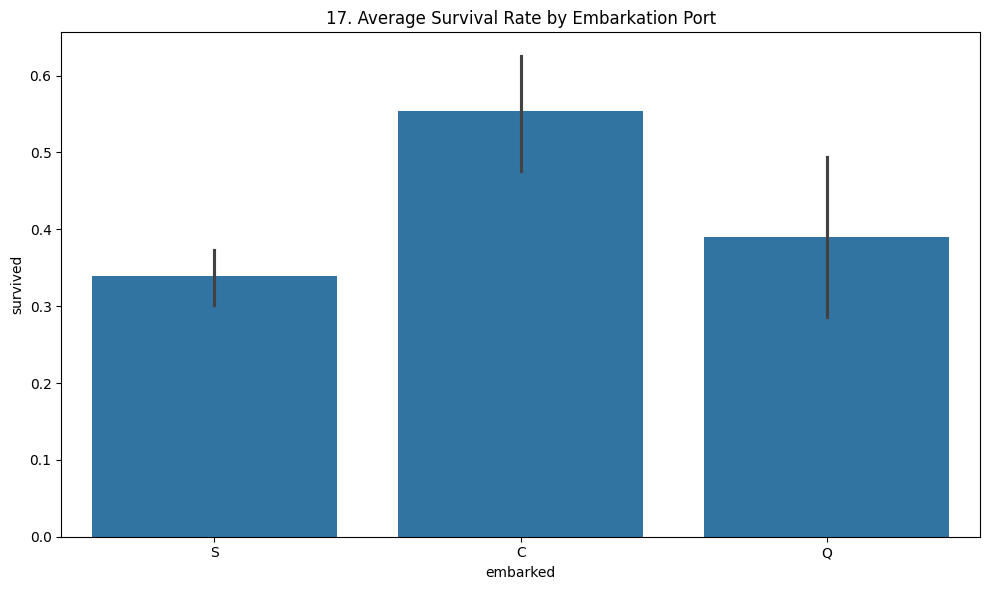

In [31]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='embarked', y='survived')
plt.title(f'{plot_no}. Average Survival Rate by Embarkation Port')
show_fig()
plot_no += 1

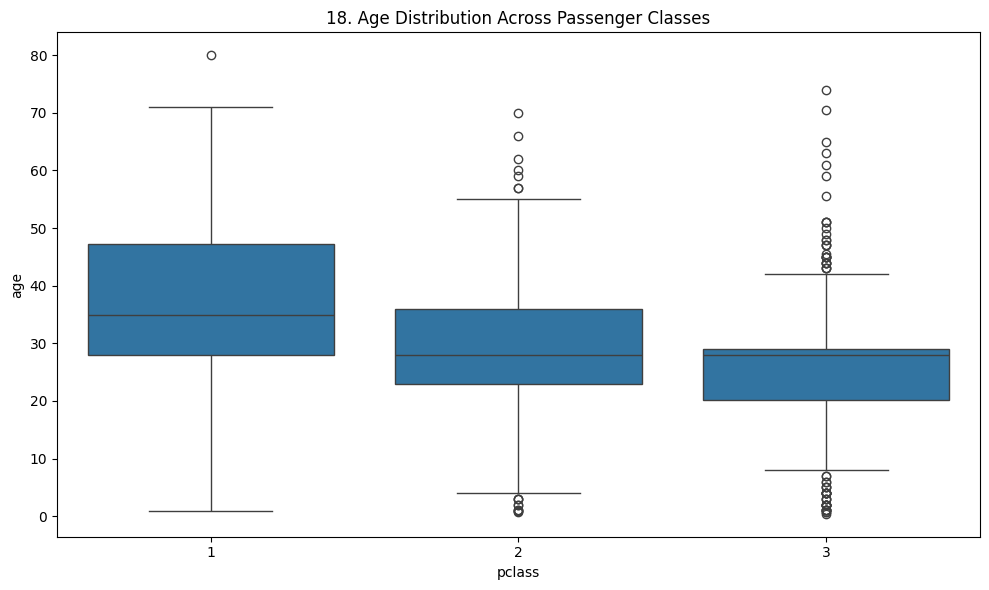

In [32]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='pclass', y='age')
plt.title(f'{plot_no}. Age Distribution Across Passenger Classes')
show_fig()
plot_no += 1

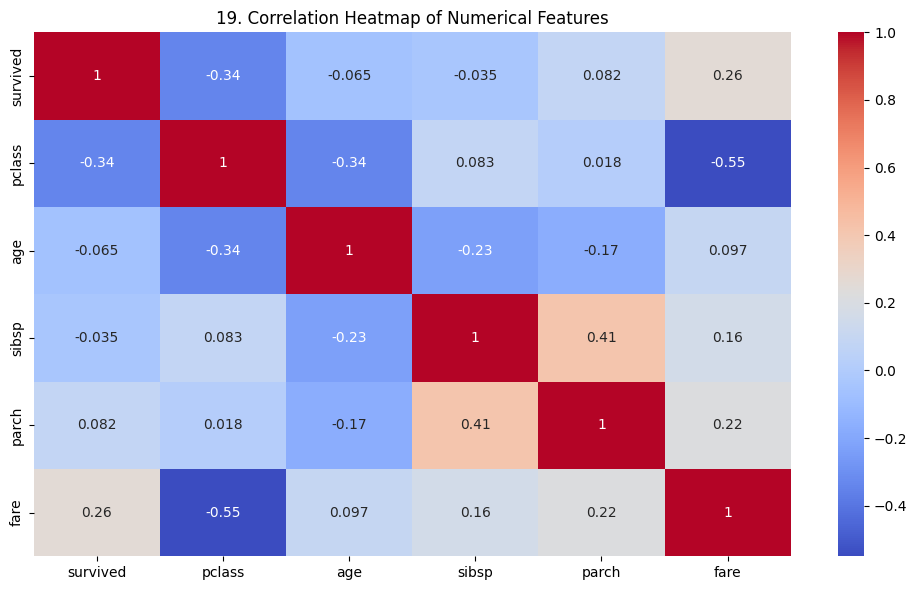

In [33]:
corr = df.select_dtypes(include='number').corr()

fig = plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title(f'{plot_no}. Correlation Heatmap of Numerical Features')
show_fig()
plot_no += 1

# Model Training

## Feature Selection

In [34]:
features = ['pclass', 'sex', 'fare', 'embarked', 'age']
target = ['survived']

## Label Encoding

In [35]:
le = LabelEncoder()

df['sex'] = le.fit_transform(df['sex'])
df['embarked'] = le.fit_transform(df['embarked'])

## Input and Target Features

In [36]:
X = df[features]
y = df[target]

## Train Test Split

In [37]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Train model With Pre-pruning

In [38]:
model = DecisionTreeClassifier(max_depth = 4, min_samples_split = 10)
model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=4, min_samples_split=10)

## Evaluate Model

In [39]:
from sklearn.metrics import accuracy_score
y_pred = model.predict(X_test)

accuracy_score(y_test, y_pred)

0.7988826815642458

## Plot Tree

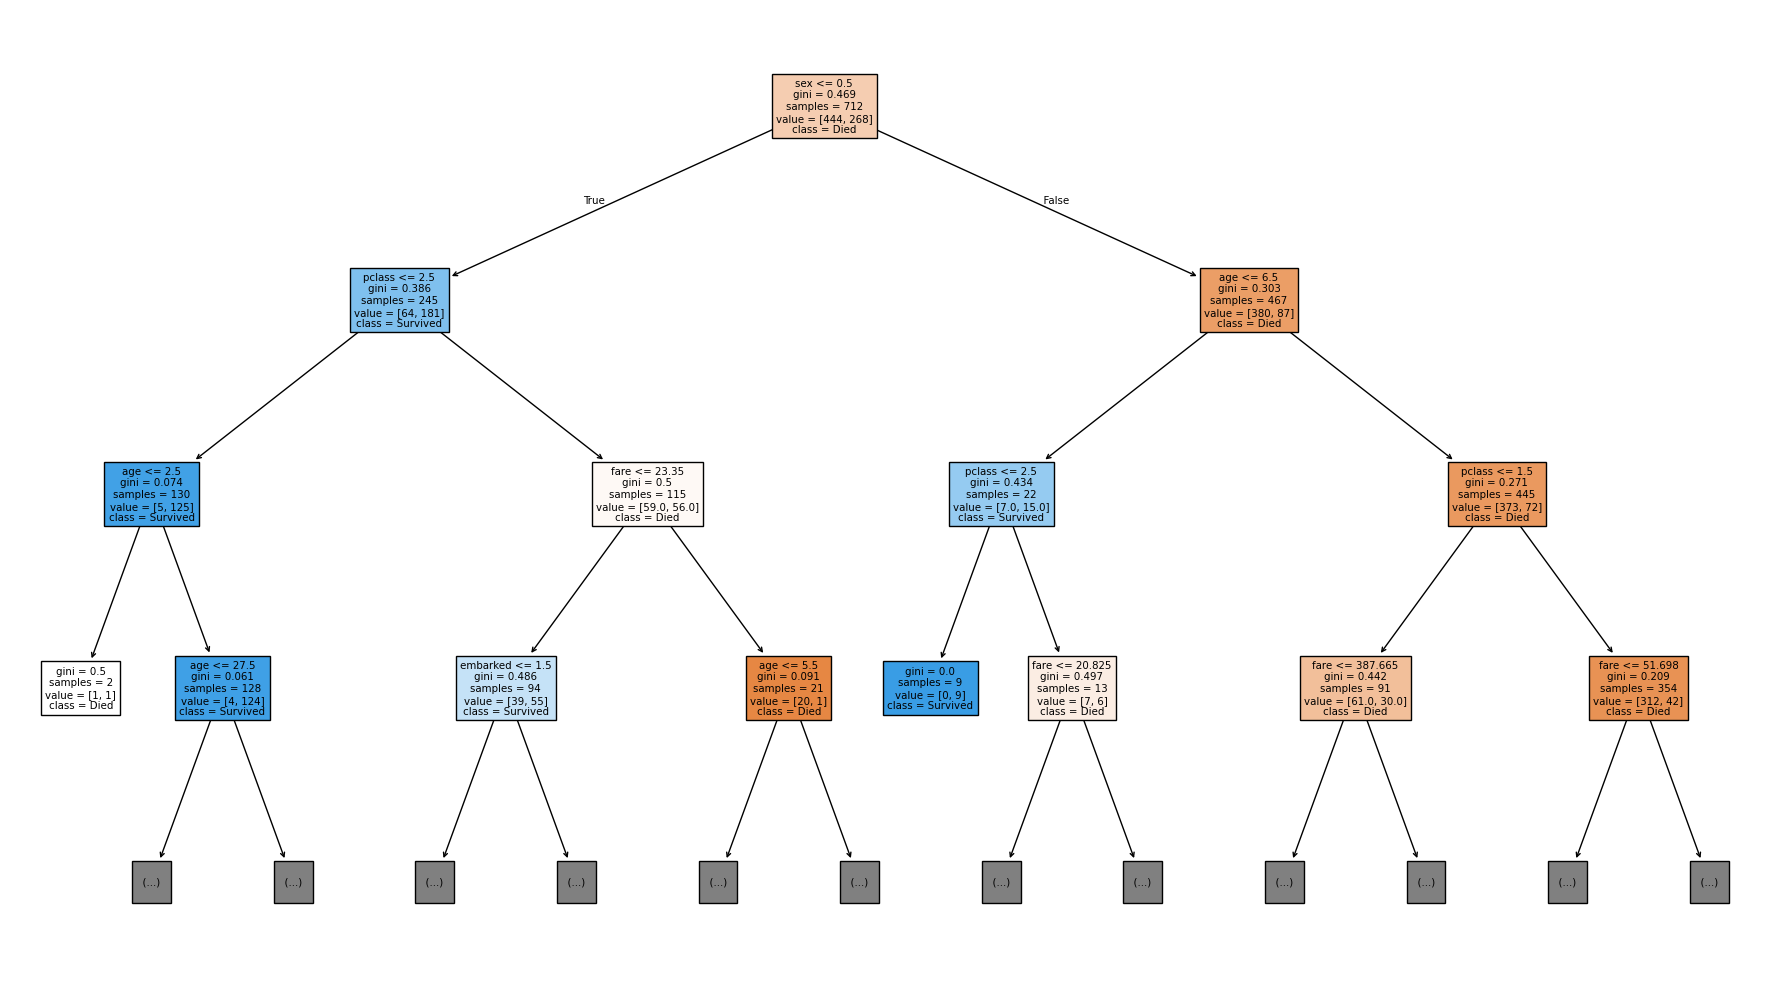

In [40]:
from sklearn.tree import plot_tree
plt.figure(figsize=(18, 10))
plot_tree(
    model,
    feature_names = X.columns,
    class_names = ["Died", "Survived"],
    filled = True,
    max_depth = 3
)
plt.tight_layout()
plt.show()